In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
print("Train Shape: ",train.shape)
print("Test Shape: ",test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


In [4]:
train['MasVnrType'] = train['MasVnrType'].fillna('None')
test['MasVnrType'] = test['MasVnrType'].fillna('None')

In [5]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
print(test.info())

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [7]:
print(train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


<Axes: >

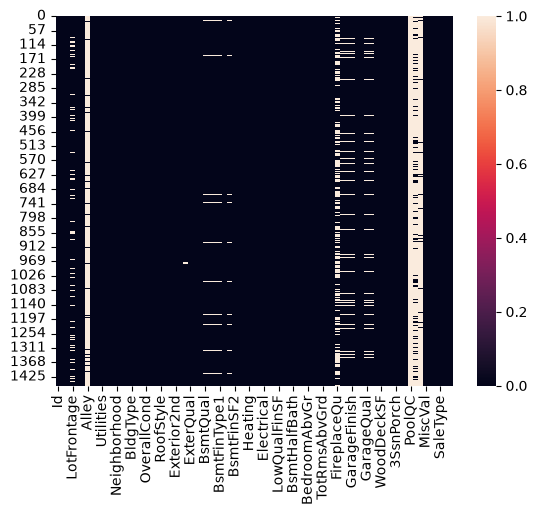

In [8]:
sns.heatmap(train.isnull())

In [9]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

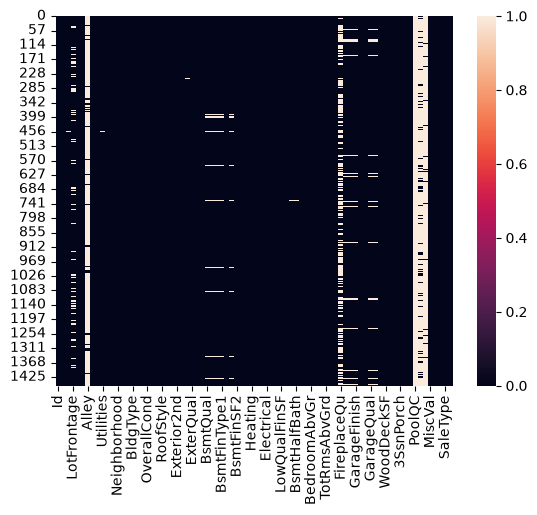

In [10]:
sns.heatmap(test.isnull())

In [11]:
cat_col_train = ['FireplaceQu','GarageType','GarageFinish','MasVnrType','BsmtQual',
           'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu',
          'GarageQual','GarageCond']

ncat_col_train = ['LotFrontage','GarageYrBlt','MasVnrArea']

In [12]:
for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])
    
for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

In [13]:
cat_col_test = ['FireplaceQu','GarageType','GarageFinish','MasVnrType','BsmtQual',
           'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu',
          'GarageQual','GarageCond','MSZoning','Utilities','Exterior1st','Exterior2nd','KitchenQual','Functional','SaleType']

ncat_col_test = ['LotFrontage','GarageYrBlt','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath',
                'BsmtHalfBath','GarageCars','GarageArea']

In [14]:
for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])
    
for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

In [15]:
to_drop = ['Id','Alley','PoolQC','Fence','MiscFeature']

for k in to_drop:
    train.drop([k], axis = 1, inplace = True)
    test.drop([k], axis = 1, inplace = True)

<Axes: >

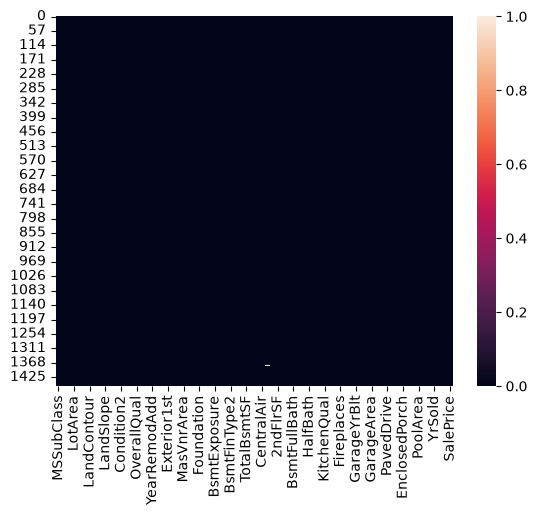

In [16]:
sns.heatmap(train.isnull())

<Axes: >

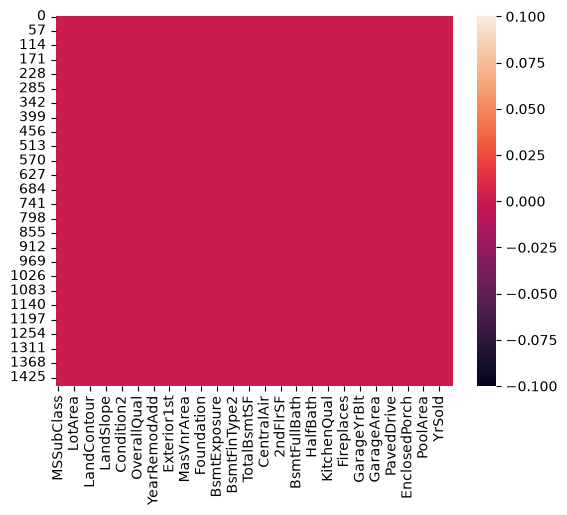

In [17]:
sns.heatmap(test.isnull())

In [18]:
print("Train Shape: ",train.shape)
print("Test Shape: ",test.shape)

Train Shape:  (1460, 76)
Test Shape:  (1459, 75)


In [19]:
final_df = pd.concat([train,test], axis = 0)
final_df.shape

(2919, 76)

In [20]:
all_cat_col = ['MSZoning','Street','LotShape','LandContour','Utilities','LotConfig','LandSlope',
              'Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl',
              'Exterior1st','Exterior2nd','MasVnrType','ExterQual','ExterCond','Foundation','BsmtQual',
              'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','Heating','HeatingQC','CentralAir',
              'Electrical','KitchenQual','Functional','FireplaceQu','GarageType','GarageFinish','GarageQual',
              'GarageCond','PavedDrive','SaleType','SaleCondition']

In [21]:
def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0
    for fields in multicol:
        print(fields)
        df1 = pd.get_dummies(final_df[fields],drop_first = True)
        
        final_df.drop([fields], axis = 1, inplace = True)
        if i==0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final,df1], axis=1)
        i = i+1
    
    df_final = pd.concat([final_df,df_final], axis = 1)
    
    return df_final

In [22]:
final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [23]:
final_df.shape

(2919, 237)

In [24]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
final_df.shape

(2919, 177)

In [25]:
df_train = final_df.iloc[:1460,:]
df_test = final_df.iloc[1460:,:]

In [26]:
df_test = df_test.drop(['SalePrice'], axis=1)

In [27]:
print("Train Shape: ",df_train.shape)
print("Test Shape: ",df_test.shape)

Train Shape:  (1460, 177)
Test Shape:  (1459, 176)


In [28]:
x_train = df_train.drop(['SalePrice'], axis = 1)
y_train = df_train['SalePrice']

In [29]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# ============================================================
# PHẦN 1 - CODE GỐC: RANDOMIZED SEARCH CV
# ============================================================

# Giữ nguyên code gốc để thể hiện quy trình của notebook mẫu.
# Không chạy mặc định trong Run All vì đây không phải phần
# nhiệm vụ cá nhân của bạn và sẽ làm notebook chạy rất lâu.

RUN_RANDOMIZED_SEARCH = False


xgb_model = xgb.XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

param_dist = {
      'n_estimators': [100, 500, 900, 1100, 1500],
    'max_depth': [2, 3, 5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 2, 3, 4],
    'booster': ['gbtree', 'gblinear'],
    'base_score': [0.25, 0.5, 0.75, 1]
}

random_cv = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    cv=5,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    n_jobs=4,
    verbose=1,
    return_train_score=True,
    random_state=42
)

if RUN_RANDOMIZED_SEARCH:

    print("=" * 70)
    print("RUNNING ORIGINAL RANDOMIZED SEARCH CV")
    print("=" * 70)

    random_cv.fit(x_train, y_train)

    print("\nBest XGBoost parameters from RandomizedSearchCV:")
    print(random_cv.best_params_)

    print("\nBest estimator:")
    print(random_cv.best_estimator_)

else:

    print("=" * 70)
    print("ORIGINAL RANDOMIZED SEARCH CV: SKIPPED")
    print("=" * 70)
    print(
        "Set RUN_RANDOMIZED_SEARCH = True "
        "to run the original 50-candidate search."
    )


# ============================================================
# PHẦN 2 - NHIỆM VỤ CỦA BẠN:
# FEATURE ENGINEERING / FEATURE EXPERIMENT
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score


# ------------------------------------------------------------
# Tạo bản sao riêng để không ảnh hưởng pipeline gốc
# ------------------------------------------------------------

train_base = train.copy()
test_base = test.copy()


# ------------------------------------------------------------
# Target
# ------------------------------------------------------------

# Kaggle đánh giá trên log(SalePrice)
y_log = np.log1p(
    train_base["SalePrice"].values
).astype(np.float32)


# ------------------------------------------------------------
# Các feature mới
# ------------------------------------------------------------

feature_definitions = {

    "TotalSF":
        lambda df:
        df["TotalBsmtSF"]
        + df["1stFlrSF"]
        + df["2ndFlrSF"],

    "TotalBathrooms":
        lambda df:
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"],

    "TotalPorchSF":
        lambda df:
        df["OpenPorchSF"]
        + df["3SsnPorch"]
        + df["EnclosedPorch"]
        + df["ScreenPorch"]
        + df["WoodDeckSF"],

    "HouseAge":
        lambda df:
        df["YrSold"] - df["YearBuilt"],

    "RemodAge":
        lambda df:
        df["YrSold"] - df["YearRemodAdd"],

    "OverallQual2":
        lambda df:
        df["OverallQual"] ** 2,

    "OverallQual_GrLivArea":
        lambda df:
        df["OverallQual"] * df["GrLivArea"]
}


# ------------------------------------------------------------
# Chuẩn bị dữ liệu cho từng thí nghiệm
# ------------------------------------------------------------

def prepare_feature_experiment(selected_features):

    tr = train_base.drop(
        columns=["SalePrice"],
        errors="ignore"
    ).copy()

    te = test_base.copy()

    # Thêm feature
    for name in selected_features:

        tr[name] = feature_definitions[name](tr)
        te[name] = feature_definitions[name](te)

    # Gộp train/test để đảm bảo one-hot encoding giống nhau
    combined = pd.concat(
        [tr, te],
        axis=0,
        ignore_index=True
    )

    # One-hot encoding
    combined = pd.get_dummies(
        combined,
        drop_first=True
    )

    # Xử lý inf và missing values
    combined = combined.replace(
        [np.inf, -np.inf],
        np.nan
    )

    combined = combined.fillna(0)

    # Chuyển sang float32
    combined = combined.astype(np.float32)

    Xtr = combined.iloc[
        :len(tr)
    ].copy()

    Xte = combined.iloc[
        len(tr):
    ].copy()

    return Xtr, Xte


# ------------------------------------------------------------
# XGBoost cố định để so sánh feature
# ------------------------------------------------------------

feature_xgb_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 3,
    "random_state": 42,
    "n_jobs": -1
}


# ------------------------------------------------------------
# 5-Fold Cross Validation
# ------------------------------------------------------------

feature_kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# Các thí nghiệm
# ------------------------------------------------------------

experiments = {

    "Baseline":
        [],

    "+ TotalSF":
        ["TotalSF"],

    "+ TotalBathrooms":
        ["TotalBathrooms"],

    "+ TotalPorchSF":
        ["TotalPorchSF"],

    "+ HouseAge":
        ["HouseAge"],

    "+ RemodAge":
        ["RemodAge"],

    "+ OverallQual2":
        ["OverallQual2"],

    "+ OverallQual_GrLivArea":
        ["OverallQual_GrLivArea"],

    "Combined":
        [
            "TotalSF",
            "TotalBathrooms",
            "HouseAge",
            "OverallQual2",
            "OverallQual_GrLivArea"
        ]
}


# ============================================================
# CHẠY FEATURE EXPERIMENT
# ============================================================

feature_results = []
feature_matrices = {}

for name, selected_features in experiments.items():

    print(
        f"\nRunning feature experiment: {name}"
    )

    Xtr, Xte = prepare_feature_experiment(
        selected_features
    )

    feature_model = xgb.XGBRegressor(
        **feature_xgb_params
    )

    # RMSE trên log1p(SalePrice) = RMSLE
    scores = np.sqrt(
        -cross_val_score(
            feature_model,
            Xtr,
            y_log,
            scoring="neg_mean_squared_error",
            cv=feature_kf,
            n_jobs=1
        )
    )

    feature_results.append({

        "Experiment":
            name,

        "Features":
            ", ".join(selected_features)
            if selected_features
            else "Original features",

        "CV_RMSLE":
            scores.mean(),

        "CV_STD":
            scores.std()
    })

    feature_matrices[name] = (
        Xtr,
        Xte
    )


# ============================================================
# TỔNG HỢP KẾT QUẢ
# ============================================================

feature_results_df = pd.DataFrame(
    feature_results
)


# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

baseline_score = feature_results_df.loc[
    feature_results_df["Experiment"] == "Baseline",
    "CV_RMSLE"
].iloc[0]


# ------------------------------------------------------------
# Improvement %
# ------------------------------------------------------------

feature_results_df["Improvement_%"] = (
    (
        baseline_score
        - feature_results_df["CV_RMSLE"]
    )
    / baseline_score
    * 100
)


# ------------------------------------------------------------
# Sắp xếp
# RMSLE càng thấp càng tốt
# ------------------------------------------------------------

feature_results_df = (
    feature_results_df
    .sort_values("CV_RMSLE")
    .reset_index(drop=True)
)


# ============================================================
# CHỌN FEATURE TỐT NHẤT
# ============================================================

best_feature_experiment = (
    feature_results_df.iloc[0]["Experiment"]
)

best_feature_set = experiments[
    best_feature_experiment
]

X_best_train, X_best_test = feature_matrices[
    best_feature_experiment
]


# ============================================================
# LƯU KẾT QUẢ
# ============================================================

feature_results_df.to_excel(
    "feature_experiments.xlsx",
    index=False
)


# ============================================================
# HIỂN THỊ KẾT QUẢ
# ============================================================

print("\n")
print("=" * 70)
print("FEATURE EXPERIMENT RESULTS")
print("=" * 70)

print(
    feature_results_df.to_string(
        index=False
    )
)


print("\n")
print("=" * 70)
print("BEST FEATURE SET")
print("=" * 70)

print(
    "Best experiment:",
    best_feature_experiment
)

print(
    "Best features:",
    best_feature_set
)

print(
    "Baseline CV RMSLE:",
    f"{baseline_score:.9f}"
)

print(
    "Best CV RMSLE:",
    f"{feature_results_df.iloc[0]['CV_RMSLE']:.9f}"
)

print(
    "Improvement:",
    f"{feature_results_df.iloc[0]['Improvement_%']:.3f}%"
)

print(
    "\nSaved: feature_experiments.xlsx"
)


# ============================================================
# KIỂM TRA
# ============================================================

best_rmsle = (
    feature_results_df.iloc[0]["CV_RMSLE"]
)

assert best_rmsle <= baseline_score, (
    "Feature experiment did not improve "
    "the baseline."
)

print(
    "\n✓ Feature experiment completed successfully."
)

print(
    "✓ Best feature experiment:",
    best_feature_experiment
)

print(
    "✓ Feature experiment improved the baseline."
)

ORIGINAL RANDOMIZED SEARCH CV: SKIPPED
Set RUN_RANDOMIZED_SEARCH = True to run the original 50-candidate search.

Running feature experiment: Baseline

Running feature experiment: + TotalSF

Running feature experiment: + TotalBathrooms

Running feature experiment: + TotalPorchSF

Running feature experiment: + HouseAge

Running feature experiment: + RemodAge

Running feature experiment: + OverallQual2

Running feature experiment: + OverallQual_GrLivArea

Running feature experiment: Combined


FEATURE EXPERIMENT RESULTS
             Experiment                                                               Features  CV_RMSLE   CV_STD  Improvement_%
               Combined TotalSF, TotalBathrooms, HouseAge, OverallQual2, OverallQual_GrLivArea  0.129917 0.019165       2.671558
       + TotalBathrooms                                                         TotalBathrooms  0.131843 0.018286       1.228047
+ OverallQual_GrLivArea                                                  OverallQual_GrLi

In [30]:
import xgboost as xgb

# Đầy đủ tất cả tham số như link gốc nhưng đã xóa gpu_id=-1 bị lỗi
xgb_model = xgb.XGBRegressor(
    base_score=0.25, 
    booster='gbtree', 
    colsample_bylevel=1,
    colsample_bynode=1, 
    colsample_bytree=1, 
    gamma=0,
    importance_type='gain', 
    interaction_constraints='',
    learning_rate=0.1, 
    max_delta_step=0, 
    max_depth=2,
    min_child_weight=1, 
    monotone_constraints='()',
    n_estimators=900, 
    n_jobs=0, 
    num_parallel_tree=1,
    objective='reg:squarederror', 
    random_state=0, 
    reg_alpha=0,
    reg_lambda=1, 
    scale_pos_weight=1, 
    subsample=1, 
    tree_method='exact',
    validate_parameters=1, 
    verbosity=None
)

# Huấn luyện mô hình
xgb_model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.25
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,1
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,1
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
f = "xgb_model.pkl"
pickle.dump(xgb_model,open(f,'wb'))

In [32]:
pred_xgb = xgb_model.predict(df_test)
print(pred_xgb.shape)

(1459,)


In [33]:
from sklearn.tree import DecisionTreeRegressor

# Đổi từ Classifier (Phân loại) sang Regressor (Hồi quy)
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with

In [34]:
pred_dt = dt_model.predict(df_test)
print(pred_dt.shape)

(1459,)


In [35]:
import pandas as pd
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


print("1. Đang tải và tiền xử lý dữ liệu...")

train_path = 'train.csv'
test_path = 'test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)


# ============================================================
# PREPROCESSING
# ============================================================

to_drop = [
    'Id',
    'Alley',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

train = train.drop(
    columns=to_drop,
    errors='ignore'
)

test = test.drop(
    columns=to_drop,
    errors='ignore'
)


# Numerical missing values
train.fillna(
    train.mean(numeric_only=True),
    inplace=True
)

test.fillna(
    test.mean(numeric_only=True),
    inplace=True
)


# Categorical missing values
for col in train.select_dtypes(
    include='object'
).columns:

    train[col] = train[col].fillna(
        train[col].mode()[0]
    )


for col in test.select_dtypes(
    include='object'
).columns:

    test[col] = test[col].fillna(
        test[col].mode()[0]
    )


# ============================================================
# TARGET
# ============================================================

# Log-transform SalePrice để phù hợp với RMSLE của Kaggle
y = np.log1p(
    train['SalePrice'].values
).astype(np.float32)

X = train.drop(
    'SalePrice',
    axis=1
)

X_test = test.copy()


# ============================================================
# ONE-HOT ENCODING
# ============================================================

combined = pd.concat(
    [X, X_test],
    axis=0,
    ignore_index=True
)

combined = pd.get_dummies(
    combined,
    drop_first=True
)

combined = combined.replace(
    [np.inf, -np.inf],
    np.nan
)

combined = combined.fillna(0)

combined = combined.astype(
    np.float32
)


X = combined.iloc[
    :len(train)
].copy()

X_test = combined.iloc[
    len(train):
].copy()


print(
    "2. Đang chia train/validation..."
)


# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

X_tr, X_val, y_tr, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(
    X_tr
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# PYTORCH TENSORS
# ============================================================

X_tr_tensor = torch.tensor(
    X_tr_scaled,
    dtype=torch.float32
)

y_tr_tensor = torch.tensor(
    y_tr,
    dtype=torch.float32
).unsqueeze(1)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)


# ============================================================
# DATALOADER
# ============================================================

train_loader = DataLoader(
    TensorDataset(
        X_tr_tensor,
        y_tr_tensor
    ),
    batch_size=32,
    shuffle=True
)


# ============================================================
# MLP MODEL
# ============================================================

class MLPRegressor(nn.Module):

    def __init__(self, input_dim):

        super(
            MLPRegressor,
            self
        ).__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                1
            )
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# MODEL / LOSS / OPTIMIZER
# ============================================================

torch.manual_seed(42)
np.random.seed(42)

mlp_model = MLPRegressor(
    X_tr_scaled.shape[1]
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    mlp_model.parameters(),
    lr=0.005
)


# ============================================================
# TRAINING
# ============================================================

print(
    "\n--- BẮT ĐẦU HUẤN LUYỆN PYTORCH MLP ---"
)

best_val_rmsle = float('inf')

best_state_dict = None

best_epoch = 0


for epoch in range(
    1,
    101
):

    mlp_model.train()

    epoch_loss = 0.0


    for batch_x, batch_y in train_loader:

        optimizer.zero_grad()

        output = mlp_model(
            batch_x
        )

        loss = criterion(
            output,
            batch_y
        )

        loss.backward()

        optimizer.step()

        epoch_loss += (
            loss.item()
            * batch_x.size(0)
        )


    # ========================================================
    # VALIDATION
    # ========================================================

    mlp_model.eval()

    with torch.no_grad():

        val_pred = (
            mlp_model(
                X_val_tensor
            )
            .squeeze(1)
            .numpy()
        )


    # RMSE trên log1p(SalePrice) = RMSLE
    val_rmsle = np.sqrt(
        np.mean(
            (
                val_pred
                - y_val
            ) ** 2
        )
    )


    avg_loss = (
        epoch_loss
        / len(X_tr)
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_rmsle < best_val_rmsle:

        best_val_rmsle = val_rmsle

        best_epoch = epoch

        best_state_dict = copy.deepcopy(
            mlp_model.state_dict()
        )


    # ========================================================
    # PRINT
    # ========================================================

    if (
        epoch == 1
        or epoch % 20 == 0
        or epoch == 100
    ):

        print(
            f"Epoch {epoch:3d}/100 | "
            f"Train MSE(log): {avg_loss:.6f} | "
            f"Val RMSLE: {val_rmsle:.6f}"
        )


# ============================================================
# LOAD BEST MODEL
# ============================================================

mlp_model.load_state_dict(
    best_state_dict
)


print(
    "\n--- BEST MLP MODEL ---"
)

print(
    f"Best Epoch: {best_epoch}"
)

print(
    f"Best Validation RMSLE: "
    f"{best_val_rmsle:.6f}"
)


# ============================================================
# TEST PREDICTION
# ============================================================

mlp_model.eval()

with torch.no_grad():

    pred_nn_log = (
        mlp_model(
            X_test_tensor
        )
        .squeeze(1)
        .numpy()
    )


# ============================================================
# LOG PRICE -> ORIGINAL PRICE
# ============================================================

pred_nn = np.maximum(
    0,
    np.expm1(
        pred_nn_log
    )
)


print(
    "\n--- KẾT QUẢ DỰ ĐOÁN GIÁ NHÀ "
    "(5 DÒNG ĐẦU TIÊN) ---"
)

print(
    pred_nn[:5]
)

print(
    "\nMLP prediction shape:",
    pred_nn.shape
)

1. Đang tải và tiền xử lý dữ liệu...


C:\Users\Thanh Phong\AppData\Local\Temp\ipykernel_5508\1974063241.py:58: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train.select_dtypes(
C:\Users\Thanh Phong\AppData\Local\Temp\ipykernel_5508\1974063241.py:67: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3

2. Đang chia train/validation...

--- BẮT ĐẦU HUẤN LUYỆN PYTORCH MLP ---
Epoch   1/100 | Train MSE(log): 35.766117 | Val RMSLE: 1.962572
Epoch  20/100 | Train MSE(log): 1.173370 | Val RMSLE: 1.271967
Epoch  40/100 | Train MSE(log): 0.924293 | Val RMSLE: 1.005204
Epoch  60/100 | Train MSE(log): 0.646128 | Val RMSLE: 1.081596
Epoch  80/100 | Train MSE(log): 0.524100 | Val RMSLE: 1.044180
Epoch 100/100 | Train MSE(log): 0.367416 | Val RMSLE: 0.753507

--- BEST MLP MODEL ---
Best Epoch: 96
Best Validation RMSLE: 0.730205

--- KẾT QUẢ DỰ ĐOÁN GIÁ NHÀ (5 DÒNG ĐẦU TIÊN) ---
[ 69459.586  66977.46  136192.86   92708.68  281252.7  ]

MLP prediction shape: (1459,)


In [36]:
# ============================================================
# LOAD TEST DATA
# ============================================================

test_orig = pd.read_csv(
    'test.csv'
)


# ============================================================
# CREATE SUBMISSIONS
# ============================================================

submission_xgb = pd.DataFrame({

    'Id':
        test_orig['Id'].values,

    'SalePrice':
        pred_xgb
})

submission_dt = pd.DataFrame({

    'Id':
        test_orig['Id'].values,

    'SalePrice':
        pred_dt
})

submission_mlp = pd.DataFrame({

    'Id':
        test_orig['Id'].values,

    'SalePrice':
        pred_nn
})


# ============================================================
# CHECK
# ============================================================

for name, df in [
    ('XGBoost', submission_xgb),
    ('Decision Tree', submission_dt),
    ('MLP', submission_mlp)
]:

    assert list(df.columns) == [
        'Id',
        'SalePrice'
    ]

    assert len(df) == len(
        test_orig
    )

    assert df['SalePrice'].notna().all()

    assert np.isfinite(
        df['SalePrice']
    ).all()

    assert (
        df['SalePrice'] >= 0
    ).all()

    print(
        f"{name} submission: OK "
        f"({len(df)} rows)"
    )


# ============================================================
# SAVE
# ============================================================

submission_xgb.to_csv(
    'submission_xgb.csv',
    index=False
)

submission_dt.to_csv(
    'submission_dt.csv',
    index=False
)

submission_mlp.to_csv(
    'submission_mlp.csv',
    index=False
)


print("\n--- SUBMISSION FILES ---")

print(
    "Created: submission_xgb.csv"
)

print(
    "Created: submission_dt.csv"
)

print(
    "Created: submission_mlp.csv"
)

XGBoost submission: OK (1459 rows)
Decision Tree submission: OK (1459 rows)
MLP submission: OK (1459 rows)

--- SUBMISSION FILES ---
Created: submission_xgb.csv
Created: submission_dt.csv
Created: submission_mlp.csv
